# 🏥 Hospital Readmission Prediction (UCI Diabetes Dataset)

This project builds an interpretable machine learning model to predict hospital readmissions using the UCI Diabetes 130-US hospitals dataset. It applies real-world techniques for class imbalance, model evaluation, and interpretability using SHAP.

## 1. Introduction

Hospital readmissions are a major concern in healthcare due to their cost and potential to reflect preventable issues in care delivery. In this project, we aim to build a machine learning model that can predict whether a diabetic patient will be readmitted to the hospital using the UCI Diabetes dataset.

We will:
- Clean and prepare over 100K patient records
- Handle significant class imbalance in the target variable
- Train an XGBoost model for classification
- Evaluate performance using recall and precision-recall curves
- Use SHAP for model interpretability

This notebook walks through the end-to-end workflow from data preparation to model explanation.

## 2. Data Loading & Initial Exploration

We load the UCI Diabetes dataset containing 100K+ records across 130 hospitals. First, we inspect its shape, basic statistics, and class distribution for the `readmitted` column.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score
from xgboost import XGBClassifier, plot_importance
import shap
from pathlib import Path

# Load the data
data_path = Path("..") / "data" / "diabetic_data.csv"
df = pd.read_csv(data_path)

2. ## EDA

In [2]:
# Preview shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (101766, 50)

Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
gli

In [3]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


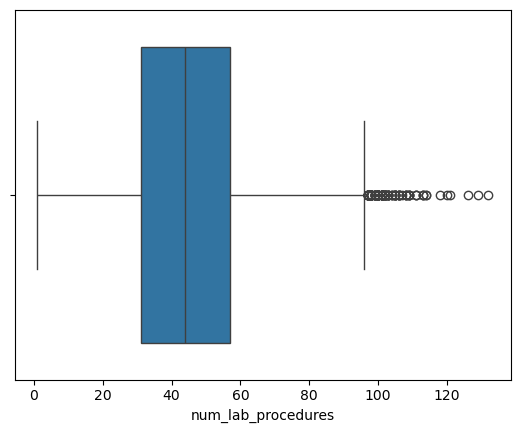

In [4]:
sns.boxplot(x=df['num_lab_procedures'])
plt.show()

In [5]:
def clip_outliers_iqr(df):
    df_clipped = df.copy()
    for col in df_clipped.select_dtypes(include=['int64', 'float64']):
        Q1 = df_clipped[col].quantile(0.25)
        Q3 = df_clipped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clipped[col] = df_clipped[col].clip(lower=lower, upper=upper)
    return df_clipped

df = clip_outliers_iqr(df)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   encounter_id              101766 non-null  int64  
 1   patient_nbr               101766 non-null  float64
 2   race                      101766 non-null  object 
 3   gender                    101766 non-null  object 
 4   age                       101766 non-null  object 
 5   weight                    101766 non-null  object 
 6   admission_type_id         101766 non-null  int64  
 7   discharge_disposition_id  101766 non-null  float64
 8   admission_source_id       101766 non-null  int64  
 9   time_in_hospital          101766 non-null  int64  
 10  payer_code                101766 non-null  object 
 11  medical_specialty         101766 non-null  object 
 12  num_lab_procedures        101766 non-null  int64  
 13  num_procedures            101766 non-null  i

## 3. Data Cleaning

We clean the dataset to ensure it is ready for machine learning:

- Drop or encode ID fields
- Replace placeholder missing values (`'?'`) with `NaN`
- Encode or drop low-utility columns
- Check and handle missing values
- Prepare categorical columns for encoding

In [7]:
df.drop(['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult'], axis=1, inplace=True)


In [8]:
# Check for placeholder '?' values
(df == '?').sum().sort_values(ascending=False)

race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
admission_type_id              0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
discharge_disposition_id       0
gender                         0
age                            0
number_outpatient              0
num_medications                0
num_procedures                 0
number_inpatient               0
number_emergency               0
number_diagnoses               0
metformin                      0
repaglinide                    0
nateglinide                    0
chlorpropamide                 0
glimepiride                    0
acetohexamide                  0
glipizide                      0
glyburide                      0
tolbutamide                    0
pioglitazone                   0
rosiglitazone                  0
acarbose                       0
miglitol                       0
troglitazo

In [9]:
df.replace('?', np.nan, inplace=True)

In [10]:
# Impute 'race' with the most frequent category
df['race'] = df['race'].fillna(df['race'].mode()[0])

# Impute diag_1/2/3 with 'Unknown'
df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].fillna('Unknown')

In [11]:
# Actual missing values (NaNs)
df.isna().sum().sort_values(ascending=False)

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipto

In [12]:
# Raw counts
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [13]:
df.gender.value_counts()


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [14]:
# 1. One-hot encode 'gender' and assign to X
df = pd.get_dummies(df, columns=['gender'])

# 2. Ensure all expected dummy columns exist (safe even if a value is missing)
for col in ['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']:
    if col not in df.columns:
        df[col] = 0

# 3. Cast the dummy columns to int
df[['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']] = df[['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      101766 non-null  object 
 1   age                       101766 non-null  object 
 2   admission_type_id         101766 non-null  int64  
 3   discharge_disposition_id  101766 non-null  float64
 4   admission_source_id       101766 non-null  int64  
 5   time_in_hospital          101766 non-null  int64  
 6   num_lab_procedures        101766 non-null  int64  
 7   num_procedures            101766 non-null  int64  
 8   num_medications           101766 non-null  int64  
 9   number_outpatient         101766 non-null  int64  
 10  number_emergency          101766 non-null  int64  
 11  number_inpatient          101766 non-null  float64
 12  diag_1                    101766 non-null  object 
 13  diag_2                    101766 non-null  o

In [15]:
df.race.value_counts()

race
Caucasian          78372
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [16]:
df = pd.get_dummies(df, columns=['race'], prefix='race')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  object 
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  float64
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  float64
 11  diag_1                    101766 non-null  object 
 12  diag_2                    101766 non-null  object 
 13  diag_3                    101766 non-null  o

In [18]:
df.age.value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [19]:
age_map = {
    '[0-10)'   : 0,
    '[10-20)'  : 1,
    '[20-30)'  : 2,
    '[30-40)'  : 3,
    '[40-50)'  : 4,
    '[50-60)'  : 5,
    '[60-70)'  : 6,
    '[70-80)'  : 7,
    '[80-90)'  : 8,
    '[90-100)' : 9
}

df['age'] = df['age'].map(age_map)

In [20]:
df.age.value_counts()

age
7    26068
6    22483
5    17256
8    17197
4     9685
3     3775
9     2793
2     1657
1      691
0      161
Name: count, dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  int64  
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  float64
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  float64
 11  diag_1                    101766 non-null  object 
 12  diag_2                    101766 non-null  object 
 13  diag_3                    101766 non-null  o

In [22]:
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in drug_columns:
    df[col] = df[col].apply(lambda x: 0 if x == 'No' else 1)

In [23]:
df['change'] = df['change'].apply(lambda x: 1 if x == 'Ch' else 0)
df['diabetesMed'] = df['diabetesMed'].apply(lambda x: 1 if x == 'Yes' else 0)

In [24]:
def map_diagnosis(code):
    try:
        code = float(code)
    except:
        return 0  # unknown

    if 390 <= code <= 459 or code == 785:
        return 1  # Circulatory
    elif 460 <= code <= 519 or code == 786:
        return 2  # Respiratory
    elif 520 <= code <= 579 or code == 787:
        return 3  # Digestive
    elif 250 <= code < 251:
        return 4  # Diabetes
    elif 800 <= code <= 999:
        return 5  # Injury
    elif 710 <= code <= 739:
        return 6  # Musculoskeletal
    elif 580 <= code <= 629 or code == 788:
        return 7  # Genitourinary
    elif 140 <= code <= 239:
        return 8  # Neoplasms
    else:
        return 0  # Other

In [25]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('Unknown')
    df[col] = df[col].apply(map_diagnosis).astype(int)

In [26]:
# Convert 'readmitted' to 0, 1, 2:
# 1 if '<30', 2 if '>30', 0 if 'NO'
df['readmitted_binary'] = df['readmitted'].apply(
    lambda x: 1 if x == '<30' else (2 if x == '>30' else 0)
)

# Optionally drop the original column
df.drop(columns=['readmitted'], inplace=True)

# Check class distribution
print(df['readmitted_binary'].value_counts())


readmitted_binary
0    54864
2    35545
1    11357
Name: count, dtype: int64


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  int64  
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  float64
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  float64
 11  diag_1                    101766 non-null  int64  
 12  diag_2                    101766 non-null  int64  
 13  diag_3                    101766 non-null  i

In [28]:
# If you have the full DataFrame (e.g., df), do this:
y = df['readmitted_binary']
X = df.drop(columns=['readmitted_binary'])

In [29]:
print(y.unique())  # Should show: [0 1]

[0 2 1]


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


## 5. Modeling with XGBoost

In [31]:
from xgboost import XGBClassifier

# Train a multi-class classifier
model = XGBClassifier(
    objective='multi:softprob',  # or 'multi:softmax' if you want direct class output
    num_class=3,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [43]:
sample_weights = y_train.map({0: 0.618, 1: 2.987, 2: 0.954})
model.fit(X_train, y_train, sample_weight=sample_weights)


/home/ylek/miniconda3/envs/my_ds_env/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [10:51:35] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [44]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.500835216665029

In [45]:
print(y_test.value_counts(normalize=True))

readmitted_binary
0    0.539108
2    0.349268
1    0.111624
Name: proportion, dtype: float64


In [46]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.58      0.62     10973
           1       0.19      0.36      0.25      2272
           2       0.46      0.43      0.44      7109

    accuracy                           0.50     20354
   macro avg       0.44      0.45      0.44     20354
weighted avg       0.55      0.50      0.52     20354

[[6355 1804 2814]
 [ 696  812  764]
 [2356 1726 3027]]


In [47]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state': 42
    }

    model = XGBClassifier(**params)

    # Optional: use sample weights
    sample_weights = y_train.map({0: 0.618, 1: 2.987, 2: 0.954})

    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='macro')


In [48]:
# Split into smaller training and validation for faster tuning
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2025-08-04 10:56:33,803] A new study created in memory with name: no-name-87ba97be-89b4-487f-9ba7-d5d664bcf0fc
[I 2025-08-04 10:56:36,519] Trial 0 finished with value: 0.4441069901416477 and parameters: {'n_estimators': 158, 'learning_rate': 0.03795318901444926, 'max_depth': 9, 'min_child_weight': 5, 'gamma': 0.7708335348629767, 'subsample': 0.6484368066042145, 'colsample_bytree': 0.8740966393647833, 'reg_alpha': 0.006725179052015529, 'reg_lambda': 1.5962394877486892}. Best is trial 0 with value: 0.4441069901416477.
[I 2025-08-04 10:56:40,007] Trial 1 finished with value: 0.43949034193829234 and parameters: {'n_estimators': 187, 'learning_rate': 0.011455156376592253, 'max_depth': 9, 'min_child_weight': 4, 'gamma': 0.5301382635173301, 'subsample': 0.6872424982579068, 'colsample_bytree': 0.8966802571562535, 'reg_alpha': 0.34064648289016963, 'reg_lambda': 1.0310615069741413}. Best is trial 0 with value: 0.4441069901416477.
[I 2025-08-04 10:56:42,831] Trial 2 finished with value: 0.4348

In [49]:
print("Best trial:")
print(f"  F1-macro: {study.best_value:.4f}")
print("  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")


Best trial:
  F1-macro: 0.4483
  Params:
    n_estimators: 260
    learning_rate: 0.020336387752971544
    max_depth: 10
    min_child_weight: 3
    gamma: 0.330000063448839
    subsample: 0.5899250887121594
    colsample_bytree: 0.5294263990887371
    reg_alpha: 0.3815265569781142
    reg_lambda: 1.5034259071035003


In [51]:
best_params = {
    'n_estimators': 260,
    'learning_rate': 0.02034,
    'max_depth': 10,
    'min_child_weight': 3,
    'gamma': 0.33,
    'subsample': 0.5899,
    'colsample_bytree': 0.5294,
    'reg_alpha': 0.3815,
    'reg_lambda': 1.5034,
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'random_state': 42
}

In [55]:
model = XGBClassifier(**best_params)

# Use class sample weights again
sample_weights = y_train.map({0: 0.618, 1: 2.987, 2: 0.954})

model.fit(X_train, y_train, sample_weight=sample_weights)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5294, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.33, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02034, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=260,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [56]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.61      0.64     10973
           1       0.20      0.31      0.25      2272
           2       0.46      0.44      0.45      7109

    accuracy                           0.52     20354
   macro avg       0.45      0.46      0.45     20354
weighted avg       0.55      0.52      0.53     20354

[[6733 1353 2887]
 [ 730  710  832]
 [2560 1401 3148]]
